In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay

In [4]:
df = pd.read_csv("Iris.csv")
X = df.drop(["Id","Species"], axis =1)
y = df["Species"]

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
k_values = [1, 3, 5, 7, 9]
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(f"K = {k} --> Accuracy = {acc:.4f}")

K = 1 --> Accuracy = 1.0000
K = 3 --> Accuracy = 1.0000
K = 5 --> Accuracy = 1.0000
K = 7 --> Accuracy = 1.0000
K = 9 --> Accuracy = 1.0000


Accuracy: 1.0

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


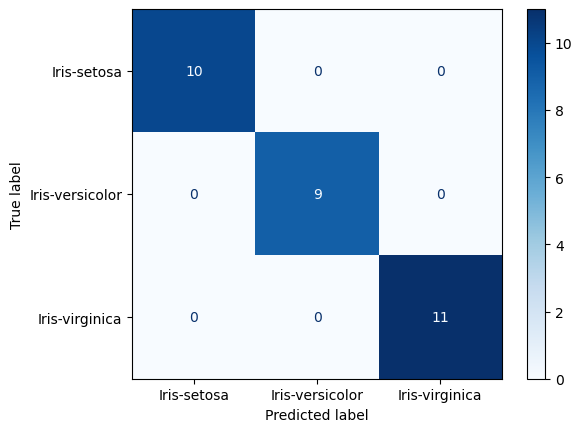

In [8]:
model = KNeighborsClassifier(n_neighbors=7)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(cmap="Blues")
plt.show()

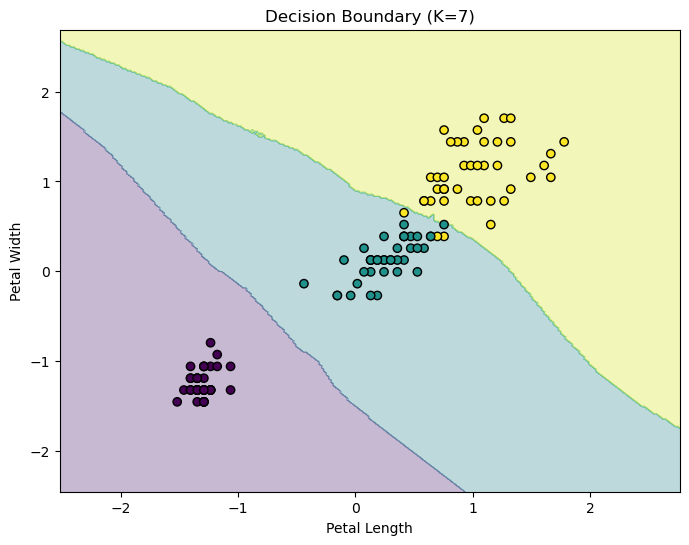

In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X = df[["PetalLengthCm", "PetalWidthCm"]]
y = le.fit_transform(df["Species"])
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)
h = 0.02

x_min, x_max = X_train[:,0].min()-1, X_train[:,0].max()+1
y_min, y_max = X_train[:,1].min()-1, X_train[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X_train[:,0],
    X_train[:,1],
    c=y_train,
    edgecolors='k'
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Decision Boundary (K=7)")
plt.show()